# Using DataChain for LLM evaluations

This notebook will show how to use DataChain for common LLM-judging-LLM cases, including how to:

- [Re-organizing text samples from CSV table](#ingesting)
- [Placing LLM API calls over input data](#processing)
- [Collecting Pydantic objects from LLM responses](#pydantic)
- [Comparative LLM analytics](#analytics)

## Setup

To start, install the dependencies and import the LLM packages. To run these examples, your will need an [API key from Mistral AI](https://console.mistral.ai/user/api-keys/ "Mistral console") (free) and [Anthropic](https://console.anthropic.com/login "Anthropic console") (paid). If you do not have an Anthropic key, these examples can be skipped.

In [65]:
%load_ext autoreload
%autoreload 2

%env MISTRAL_API_KEY=<your_mistral_api_key>
%env ANTHROPIC_API_KEY=<your_anthropic_api_key>

%pip install -q ipywidgets datachain mistralai anthropic matplotlib scikit-learn

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: MISTRAL_API_KEY=<your_mistral_api_key>
env: ANTHROPIC_API_KEY=<your_anthropic_api_key>

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import datachain as dc
from datachain import DataModel


<a id='ingesting'></a>
## Organizing text samples 

We will be using a dataset from [Karlsruhe Institute of Technology](https://radar.kit.edu/radar/en/dataset/FdJmclKpjHzLfExE.ExpBot%2B-%2BA%2Bdataset%2Bof%2B79%2Bdialogs%2Bwith%2Ban%2Bexperimental%2Bcustomer%2Bservice%2Bchatbot) which captures interactions between human experiment participants and a simple chatbot programmed to offer them a new mobile service plan. 

Evaluating the performance of a chatbot with another LLM is a common workflow and a cornerstone of many agentic applications. The task here is to go over the recorded conversations and evaluate the chatbot performance. In our particular application, the original dataset is in CSV format, similar to the below:

| id | count | sender | text |
|----------|----------|----------|----------|
| 1 | 1 | bot | Hey there! |
| 1 | 2 | bot | I'm a chatbot that helps you find a new mobile phone plan. What can I do for you?|
| 1 | 3 |user | Hi :) I need a phone plan with more MB and less minutes |
| 1 | 4 |bot | Okay, let's start! First, I need some information about your current mobile phone plan: |

In the table above, every line corresponds to one utterance of the dialog. Lines sharing the "id" field belong to the same conversation.

For our purposes, we want to group all lines that belong to the same conversation into one text block to be read by an LLM. We can do this by first parsing the CSV file at the original storage location, and then using an aggregator to reformat CSV lines into a new data model:

In [4]:
from typing import Iterator

class Dialog(DataModel):
    id: int
    text: str

def text_block(id: list[int], sender: list[str], text: list[str]) -> Iterator[Dialog]:
    columns = zip(text, sender)
    conversation = ""
    for text, sender in columns:
       conversation = "\n ".join([conversation,f"{sender}: {text}"])
    yield Dialog(id=id[0], text=conversation) 

chain = (
    dc
    .read_csv("gs://datachain-demo/chatbot-csv/", anon=True)
    .agg(dialog=text_block, partition_by=["id"])
    .persist()
)


Listing gs://datachain-demo: 0 objects [00:00, ? objects/s]

Generated: 0 rows [00:00, ? rows/s]

Processed: 0 rows [00:00, ? rows/s]

Download: 0.00B [00:00, ?B/s]

Parsed by pyarrow: 0rows [00:00, ?rows/s]

Generated: 0 rows [00:00, ? rows/s]

Processed: 0 rows [00:00, ? rows/s]

Processed: 0 rows [00:00, ? rows/s]

Generated: 0 rows [00:00, ? rows/s]

Now we should have collected 79 separate dialogs:

In [5]:
chain.count()

79

The schema for these dialogs should be provided by our Dialog class

In [6]:
chain.print_schema()

dialog: Dialog@v1
  id: int
  text: str


Finally, every dataset sample should capture the entire dialog as a text block:

In [7]:
first_dialog = next(chain.collect("dialog"))
print(first_dialog.text)


 bot: Hey there!
 bot: I'm a chatbot that helps you find a new mobile phone plan. What can I do for you?
 user: Hi :) I need a phone plan with more MB and less minutes
 bot: Okay, let's start! First, I need some information about your current mobile phone plan:
 bot: Who's your current mobile phone provider?
 user: SuperMobile
 bot: Okay. Which mobile phone plan do you have?
 user: Yellow Basic 1000
 bot: How much did you pay in total last month?
 user: 32.29 euro
 bot: Got it. How many minutes have you spent on the phone last month (national calls)?
 user: 652 minutes
 bot: How many text messages did you send last month?
 user: 23
 bot: How much data did you use last month?
 user: 1450
 bot: Do you often travel outside of Europe?
 user: no
 bot: Okay, final question: How much are you willing to spend on a mobile phone plan per month?
 user: not more than 30 €
 bot: Thanks, here are your information again:
 bot: Currently, you pay 32.29 € for a SuperMobile Yellow Basic 1000 plan. Last

##### <a id='processing'></a>
## Placing LLM API calls over input data

Now it is time to run our LLM evaluation. Let's ask a simple eval question: "Was this dialog successful"?
Note, this question is a bit open-ended because we have not provided the explicit success criteria; our goal is just to show the setup.

To speed things up, we can run up to 5 (maximum allowed by Mistral in a basic subscription) API calls at once. Higher rate limits are possible in the paid tiers of most providers. Modern Python APIs can also provide Pydantic models for responses, so we will take an advantage of this:

In [52]:
import os
from mistralai import Mistral
from mistralai.models import ChatCompletionResponse as MistralModel

# Note: reduce parallelism in the setting() call below if you run into rate limits
# Defaults to os.environ.get("MISTRAL_API_KEY") for auth

class ChatResponse(DataModel):
    """Custom DataModel for chat responses with usage information"""
    response: str
    input_tokens: int
    output_tokens: int

prompt = """
   You are working as a judge to evaluate the quality of a dialog." \
   You will be given a dialog. Evaluate if it was successful or not." \
   Return only a valid JSON object as a response with the following fields:" \
   "success": boolean, "reason": string, "score": float
"""


def mistral_model_to_chat_response(model: MistralModel) -> ChatResponse:
    return ChatResponse(
        response=model.choices[0].message.content,
        input_tokens=model.usage.prompt_tokens,
        output_tokens=model.usage.completion_tokens
    )

llm_mistral = (
    chain
    .settings(parallel=2)
    .setup(mistral_client=lambda: Mistral(api_key=os.getenv("MISTRAL_API_KEY", "")))
    .map(
       mistral=lambda dialog, mistral_client: mistral_model_to_chat_response(mistral_client.chat.complete(
                                          model="mistral-small-latest",
                                          response_format={"type": "json_object"},
                                          messages = [
                                             {"role": "system", "content": f"{prompt}"},
                                             {"role": "user", "content": f"{dialog.text}"}
                                          ]
                                       )),
       output=ChatResponse
    )
    .save("llm-mistral")
)


Preparing: 0 rows [00:00, ? rows/s]

Now all 79 dialogs have been processed, let us check the chain schema:

In [53]:
llm_mistral.print_schema()

dialog: Dialog@v1
  id: int
  text: str
mistral: ChatResponse@v1
  response: str
  input_tokens: int
  output_tokens: int


<a id='pydantic'></a>
## Collecting Pydantic objects from LLM responses

As we see, there is a new object of the type "ChatCompletionResponse" which came from Mistral's Pydantic model.
We can collect these objects in an iterator and examine it:


In [54]:
iter = llm_mistral.collect("mistral")
print(next(iter))

response='{\n  "success": true,\n  "reason": "The bot successfully guided the user through a series of questions to understand their needs and provided a suitable recommendation based on the user\'s input. The conversation flowed logically, and the bot handled the user\'s confirmation effectively, even when the user\'s response was not initially clear.",\n  "score": 9.5\n}' input_tokens=538 output_tokens=76


Here is the complete list of all remaining evaluations:

In [55]:
print(*map(lambda chat_response: chat_response.response, iter))

{
  "success": false,
  "reason": "The bot failed to understand and respond to the user's final intent to proceed with the recommended plan. Additionally, the bot struggled with understanding simple yes/no questions and repeated itself unnecessarily. The user's language was also not handled well, leading to a frustrating experience.",
  "score": 4.5
} {
  "success": false,
  "reason": "The bot was unable to find a suitable plan for the user due to the user's budget constraint. Additionally, the bot repeated the user's input incorrectly, stating 'SuperMobile i forgot the name plan' instead of acknowledging the user's forgetfulness. The dialog could have been improved by suggesting alternative plans that slightly exceed the user's budget or by providing more guidance on adjusting their expectations.",
  "score": 5.5
} {
  "success": false,
  "reason": "The bot failed to address the user's specific need for international calls in both recommendations. Additionally, the bot did not acknowl

<a id='analytics'></a>
## Comparative LLM analytics

One frequent situation during LLM evaluations or building agentic systems is the need to assess several LLM models at once. This can be done to assess their relative performance; construct mixtures of experts of several weaker models, etc.

This task is straightforward on DataChain because the intermediate dataset results can be easily saved and analytical queries are vectorized. For example, let us add an execution run of Anthropic LLM model to the chain:

In [59]:
import anthropic

# Note: reduce parallelism in the setting() call below if you run into rate limits
# Defaults to os.environ.get("ANTHROPIC_API_KEY") for auth

prompt = """
   You are working as a judge to evaluate the quality of a dialog." \
   You will be given a dialog. Evaluate if it was successful or not." \
   Respond only with a valid JSON object with the following fields:" \
   "success": boolean, "reason": string, "score": float. \
   Do not include any other text in the response.
"""


def claude_api_response(claude_client, content, prompt) -> ChatResponse:
    response = claude_client.messages.create(
        model="claude-3-5-haiku-latest",
        max_tokens=1024,
        system=prompt,
        messages=[
            {"role": "user", "content": f"{content}"},
        ],
    )
    return ChatResponse(
        response=response.content[0].text,
        input_tokens=response.usage.input_tokens,
        output_tokens=response.usage.output_tokens
    )
    
    
llm_mistral = dc.read_dataset("llm-mistral")

llm_mistral_claude = (
    llm_mistral
    .setup(claude_client=lambda: anthropic.Anthropic())
    .settings(parallel=4)
    .map(
        claude=lambda dialog, claude_client: claude_api_response(
            claude_client, dialog.text, prompt
        ),
        output=ChatResponse
    )
    .save("llm-mistral-claude")
)

Preparing: 0 rows [00:00, ? rows/s]

In [60]:
llm_mistral_claude.print_schema()

dialog: Dialog@v1
  id: int
  text: str
mistral: ChatResponse@v1
  response: str
  input_tokens: int
  output_tokens: int
claude: ChatResponse@v1
  response: str
  input_tokens: int
  output_tokens: int


In [61]:
iter = llm_mistral_claude.collect("claude")
print(*map(lambda chat_response: chat_response.response, iter))

{
    "success": true,
    "reason": "The dialog successfully guided the user through gathering necessary information about their current phone plan and provided a personalized recommendation within their budget constraints",
    "score": 0.9
} {
    "success": false,
    "reason": "The dialog was unsuccessful due to several communication issues, including bot's repeated inability to understand simple user inputs, user's frustration and use of profanity, and bot's rigid response patterns",
    "score": 0.3
} {
    "success": false,
    "reason": "The chatbot failed to find a suitable mobile phone plan for the user's requirements, particularly due to the low budget constraint of €9.99 per month compared to the user's current spending of €32.29",
    "score": 0.4
} {
    "success": false,
    "reason": "The chatbot did not successfully address the user's specific request for a plan with international calls. Instead, it repeated the previous conversation flow and proposed another plan wit

As we can see from the above, now the chain include schema for Claude responses.
Let's use the data we have collected to run some analytical queries:

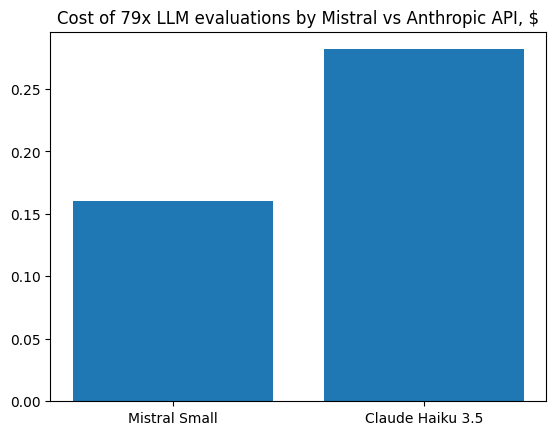

In [63]:
import matplotlib.pyplot as plt

m_input = 0.000002
m_output = 0.000006
c_input = 0.000003
c_output = 0.000015

mistral_cost = (
    llm_mistral_claude.sum("mistral.input_tokens") * m_input
    + llm_mistral_claude.sum("mistral.output_tokens") * m_output
)
claude_cost = (
    llm_mistral_claude.sum("claude.input_tokens") * c_input
    + llm_mistral_claude.sum("claude.output_tokens") * c_output
)

plt.bar(["Mistral Small", "Claude Haiku 3.5"], [mistral_cost, claude_cost])
plt.title(f"Cost of {llm_mistral_claude.count()}x LLM evaluations by Mistral vs Anthropic API, $")
plt.show()

As we can see, the open-sourced Mixtral model is cheaper to run than Claude Sonnet.
Let us see how often these two models disagree:

Preparing: 0 rows [00:00, ? rows/s]

Processed: 0 rows [00:00, ? rows/s]

Preparing: 0 rows [00:00, ? rows/s]

Processed: 0 rows [00:00, ? rows/s]

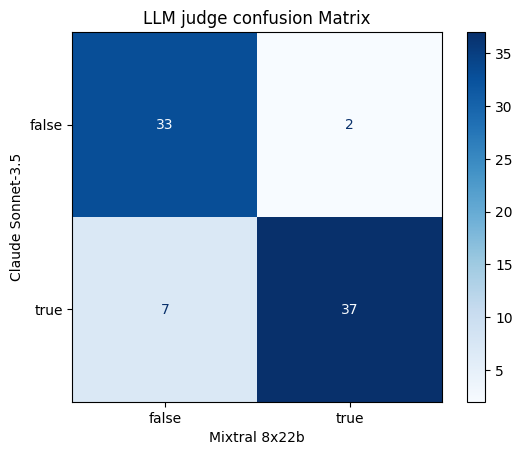

In [64]:
import json
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

new_chain = (
    dc.read_dataset("llm-mistral-claude")
    .map(mistral_rating=lambda mistral: str(json.loads(mistral.response)["success"]))
    .map(claude_rating=lambda claude: str(json.loads(claude.response)["success"]))
    .persist()
)

y_mistral = new_chain.collect("mistral_rating")
y_claude = new_chain.collect("claude_rating")

cm = confusion_matrix(list(y_claude), list(y_mistral))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["false", "true"])
disp.plot(cmap=plt.cm.Blues)

plt.title("LLM judge confusion Matrix")
plt.xlabel("Mixtral 8x22b")
plt.ylabel("Claude Sonnet-3.5")

plt.show()

As we can see from the confusion matrix, the two LLMs only disagree when Mixtral gives it a pass, while Sonnet does not.
